In [1]:
import torch
import os
import random
import utils
import data_utils
import json

import cbm
import plots

/home/hy381/project/prelim/Label-free-CBM/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


In [2]:
# change this to the correct model dir, everything else should be taken care of
load_dir = "saved_models/cub_cbm_2026_08_06_08_10"
device = "cuda"

with open(os.path.join(load_dir, "args.txt"), "r") as f:
    args = json.load(f)
dataset = args["dataset"]
_, target_preprocess = data_utils.get_target_model(args["backbone"], device)
model = cbm.load_cbm(load_dir, device)

In [3]:
val_d_probe = dataset+"_val"
cls_file = data_utils.LABEL_FILES[dataset]

val_data_t = data_utils.get_data(val_d_probe, preprocess=target_preprocess)
val_pil_data = data_utils.get_data(val_d_probe)

UnboundLocalError: cannot access local variable 'data' where it is not associated with a value

In [ ]:
with open(cls_file, "r") as f:
    classes = f.read().split("\n")

with open(os.path.join(load_dir, "concepts.txt"), "r") as f:
    concepts = f.read().split("\n")

## Measure accuracy

In [ ]:
accuracy = utils.get_accuracy_cbm(model, val_data_t, device)
print("Accuracy: {:.2f}%".format(accuracy*100))

100%|██████████| 40/40 [00:11<00:00,  3.46it/s]

Accuracy: 67.42%


## Show final layer weights for some classes

You can build a Sankey diagram of weights by copying the incoming weights printed below into https://sankeymatic.com/build/

In [ ]:
to_show = random.choices([i for i in range(len(classes))], k=1)

for i in to_show:
    print("Output class:{} - {}".format(i, classes[i]))
    print("Incoming weights:")
    for j in range(len(concepts)):
        if torch.abs(model.final.weight[i,j])>0.05:
            print("{} [{:.4f}] {}".format(concepts[j], model.final.weight[i,j], classes[i]))

Output class:89 - tractor
Incoming weights:
a blanket [-0.1988] tractor
a blowhole [-0.2901] tractor
a bright, red color [0.0550] tractor
a bucket [0.1195] tractor
a can of Raid [0.2314] tractor
a coffee cup [-0.0736] tractor
a cord [-0.0604] tractor
a cow [-0.0607] tractor
a cupboard [-0.1970] tractor
a drill [0.2219] tractor
a farmer [0.1516] tractor
a fish [-0.3776] tractor
a honeycomb [0.2550] tractor
a launch [-0.0754] tractor
a light [-0.1336] tractor
a living room [0.0616] tractor
a load of dirt [0.2388] tractor
a load of hay [0.3289] tractor
a load of lumber [0.2376] tractor
a lodge [0.0752] tractor
a long, tapered tail [-0.2469] tractor
a mane [0.1407] tractor
a mattress [0.0517] tractor
a military vehicle [0.1575] tractor
a motorcycle license [-0.2118] tractor
a mountain bike [0.0753] tractor
a office [0.0983] tractor
a pack [-0.0524] tractor
a place mat [-0.0591] tractor
a plow [0.5711] tractor
a portcullis [0.1021] tractor
a red or dark brown color [0.1750] tractor
a roach 

In [ ]:
to_show = random.choices([i for i in range(len(classes))], k=2)

top_weights, top_weight_ids = torch.topk(model.final.weight, k=5, dim=1)
bottom_weights, bottom_weight_ids = torch.topk(model.final.weight, k=5, dim=1, largest=False)

for i in to_show:
    print("Class {} - {}".format(i, classes[i]))
    out = "Highest weights: "
    for j in range(top_weights.shape[1]):
        idx = int(top_weight_ids[i, j].cpu())
        out += "{}:{:.3f}, ".format(concepts[idx], top_weights[i, j])
    print(out)
    out = "Lowest weights: "
    for j in range(bottom_weights.shape[1]):
        idx = int(bottom_weight_ids[i, j].cpu())
        out += "{}:{:.3f}, ".format(concepts[idx], bottom_weights[i, j])
    print(out + "\n")

Class 66 - raccoon
Highest weights: a bandit:0.838, a rim around the top:0.527, striped fur:0.487, primate:0.457, communication device:0.449, 
Lowest weights: a backpack:-0.722, a sunset:-0.533, a magnifying glass:-0.460, a saddle:-0.423, a net:-0.388, 

Class 32 - flatfish
Highest weights: a small mouth:0.876, a fish:0.617, a captain:0.556, a cow:0.495, seaweed:0.443, 
Lowest weights: often has towers and turrets:-0.523, a deep, dark color:-0.391, a swamp:-0.304, device:-0.284, a pacifier:-0.280, 



In [ ]:
# Some features may not have any non-zero outgoing weights, 
# i.e. these are not used by the model and should be deleted for better performance
weight_contribs = torch.sum(torch.abs(model.final.weight), dim=0)
print("Num concepts with outgoing weights:{}/{}".format(torch.sum(weight_contribs>1e-5), len(weight_contribs)))

Num concepts with outgoing weights:618/827


## Explain model reasoning for random inputs

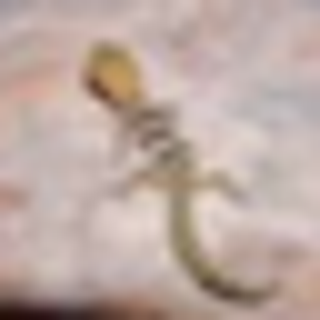

Image:2333 Gt:lizard, 1st Pred:lizard, 9.935, 2nd Pred:snake, 8.021


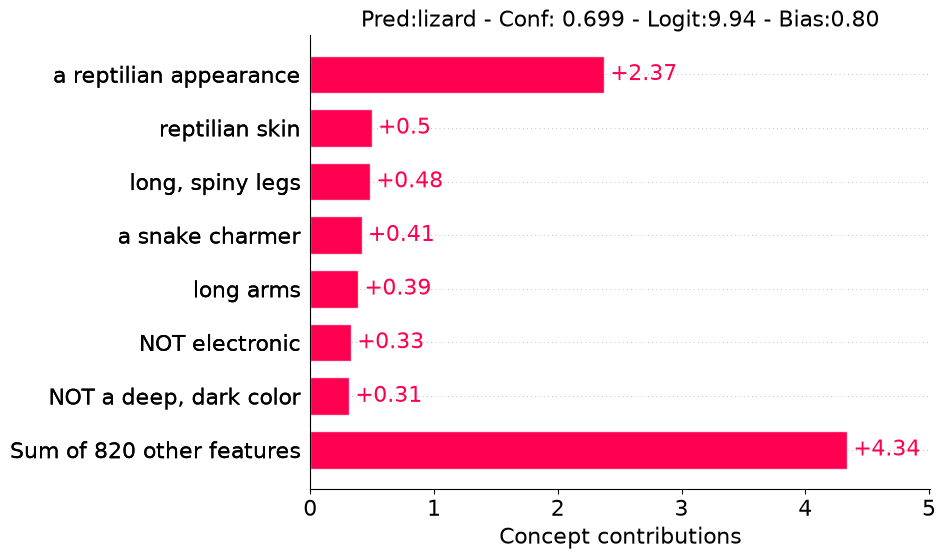

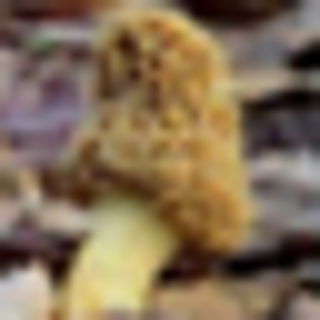

Image:7483 Gt:mushroom, 1st Pred:mushroom, 8.203, 2nd Pred:snake, 6.756


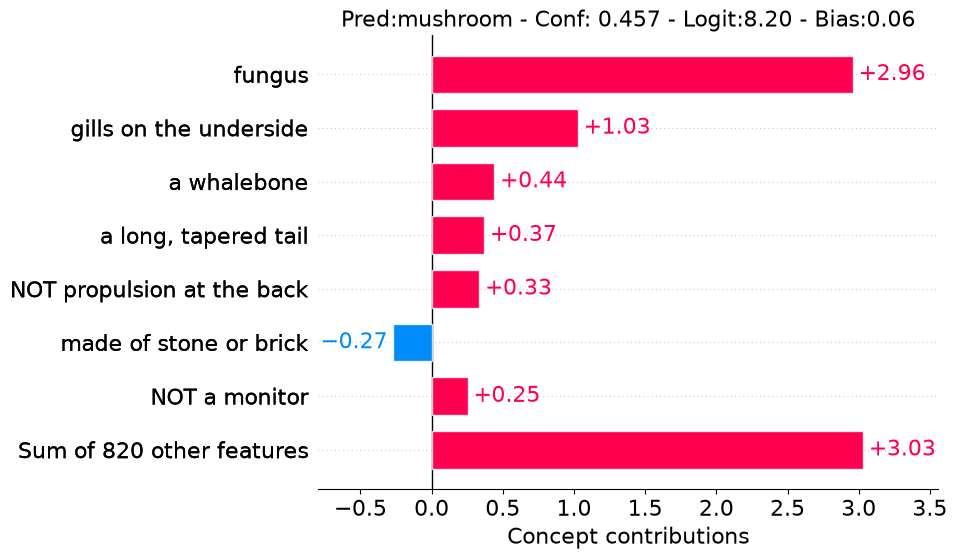

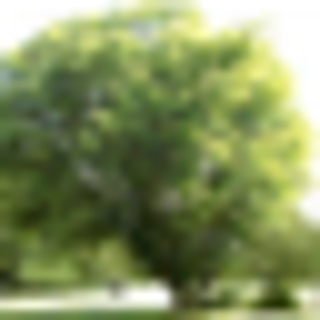

Image:9320 Gt:maple tree, 1st Pred:maple tree, 13.554, 2nd Pred:willow tree, 13.009


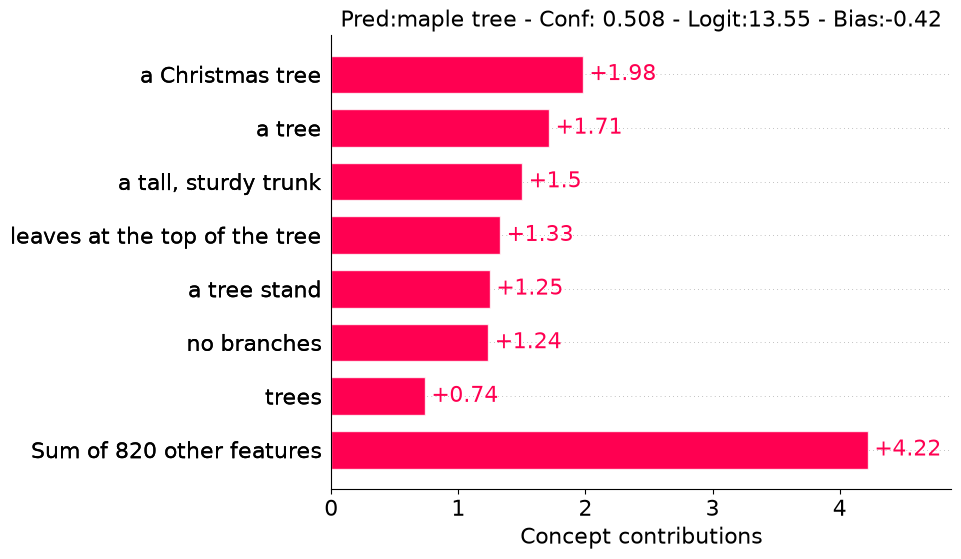

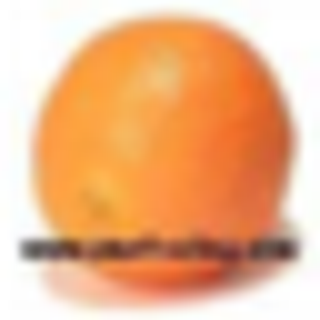

Image:2467 Gt:orange, 1st Pred:orange, 9.526, 2nd Pred:bowl, 7.286


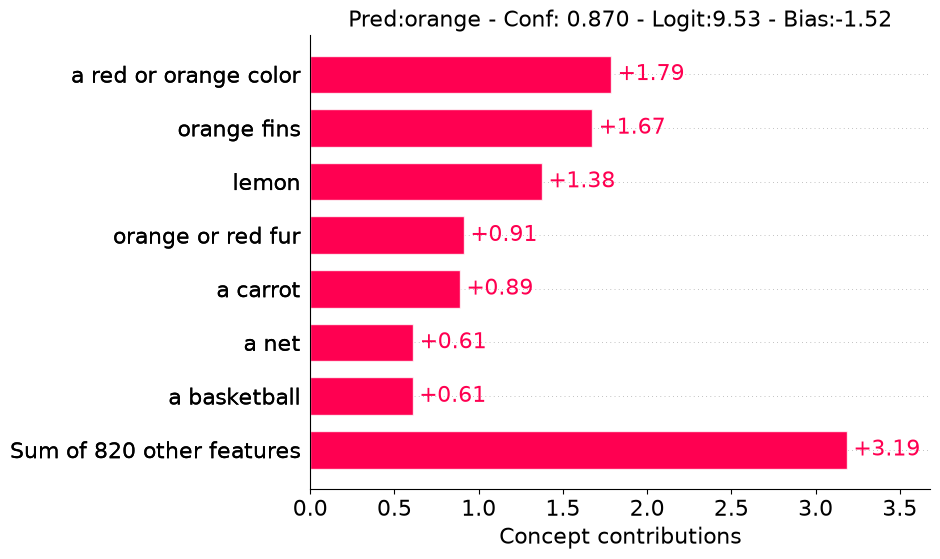

In [ ]:
to_display = random.sample([i for i in range(len(val_pil_data))], k=4)

with torch.no_grad():
    for i in to_display:
        image, label = val_pil_data[i]
        x, _ = val_data_t[i]
        x = x.unsqueeze(0).to(device)
        display(image.resize([320,320]))
        
        outputs, concept_act = model(x)
        
        top_logit_vals, top_classes = torch.topk(outputs[0], dim=0, k=2)
        conf = torch.nn.functional.softmax(outputs[0], dim=0)
        print("Image:{} Gt:{}, 1st Pred:{}, {:.3f}, 2nd Pred:{}, {:.3f}".format(i, classes[int(label)], classes[top_classes[0]], top_logit_vals[0],
                                                                      classes[top_classes[1]], top_logit_vals[1]))
        
        for k in range(1):
            contributions = concept_act[0]*model.final.weight[top_classes[k], :]
            feature_names = [("NOT " if concept_act[0][i] < 0 else "") + concepts[i] for i in range(len(concepts))]
            values = contributions.cpu().numpy()
            max_display = min(int(sum(abs(values)>0.005))+1, 8)
            title = "Pred:{} - Conf: {:.3f} - Logit:{:.2f} - Bias:{:.2f}".format(classes[top_classes[k]],
                             conf[top_classes[k]], top_logit_vals[k], model.final.bias[top_classes[k]])
            plots.bar(values, feature_names, max_display=max_display, title=title, fontsize=16)